M. Riziq Sirfatullah Alfarizi <br>
i.2211266


# K-Neares_Neighbor

Apa itu K-Neighbors (KNN)

K-Neighbors Neighbor adalah salah satu algoritma Supervised Learning yang digunakan untuk klasifikasi dan regresi. algoritma ini bekerja dengan cara:

1. menghitung jarak antara data bari yang ingin diprediksi dengan data-data dalam dataset (Biasanya menggunakan jarak Euclidean / euclidean distance).
2. menentukan sejumlah K data terdekat (K-nearest neighbors) dari data baru tersebut.
3. untuk klasifikasi, algoritma akan memberikan label kelas berdasarkan mayoritas label dari tetangga terdekat. untuk regresi, nilai prediksi diambil dari rata-rata nilai tentanganya

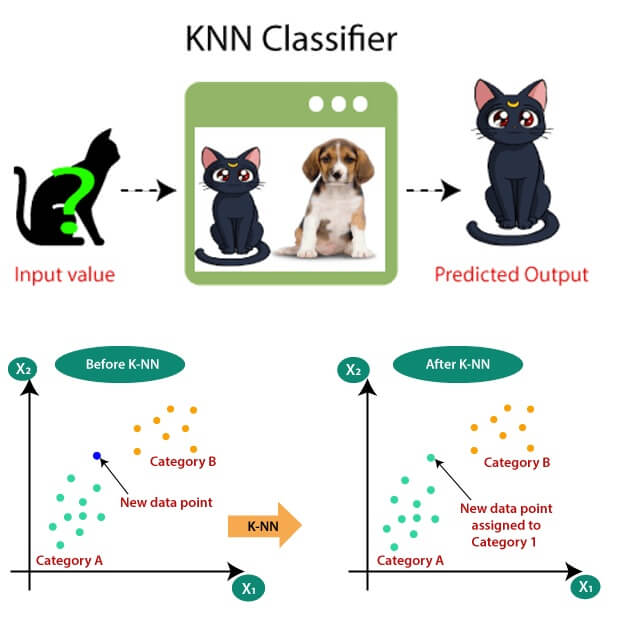

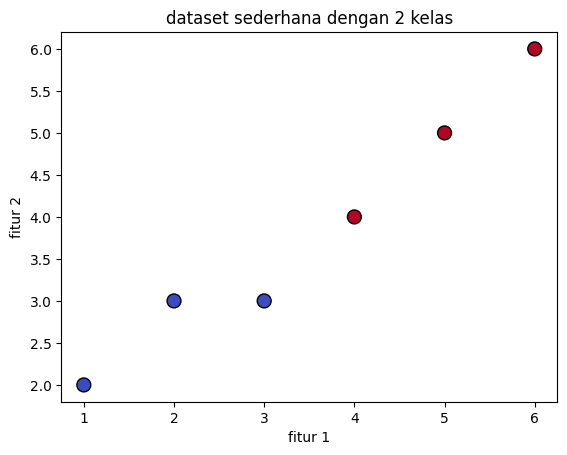

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# buat data sederhana
x = np.array([
    [1,2],[2,3],[3,3],[4,4],[5,5],[6,6]
])
y = np.array([0,0,0,1,1,1]) # Label (2 classes): 0 dan 1

# visualsasi datset
plt.scatter(x[:,0], x[:,1], c = y,cmap= 'coolwarm', s=100, edgecolors='k', label='data points' )
# c = y gambar titiknya punya warna sesuai kelas pada y, s adalah ukuran datan point
plt.title('dataset sederhana dengan 2 kelas')
plt.xlabel('fitur 1')
plt.ylabel('fitur 2')
plt.show()


In [ ]:
def plot_batas_knn(k):
  # Buat Classifier Knn
  knn = KNeighborsClassifier(n_neighbors= k)
  knn.fit(x,y)

  # buat grid untuk manampilkan batas keputusan (decision  boundaries)
  x_min, x_max, =x[:,0].min() -1, x[:,0].max() + 1
  y_min, y_max, =x[:,1].min() -1, x[:,1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min,x_max, 0.1),
                       np.arange(y_min,y_max, 0.1))
  #perediksi kelas untuk setiap titik di grid
  z = knn.predict(np.c_[xx.ravel(),yy.ravel()]) # mengubah array 2D menjadi 1D, c_ untuk combine
  z = z.reshape(xx.shape)

  plt.figure(figsize=(8,6))
  plt.contourf(xx, yy, z, alpha=0.4, cmap='coolwarm')

  plt.scatter(x[:,0], x[:,1], c = y,cmap= 'coolwarm', s=100, edgecolors='k', label='data points' )
  # c = y gambar titiknya punya warna sesuai kelas pada y, s adalah ukuran datan point
  plt.title(f'Decision Boundaries KNN (k={k}) ')
  plt.xlabel('fitur 1')
  plt.ylabel('fitur 2')
  plt.show()


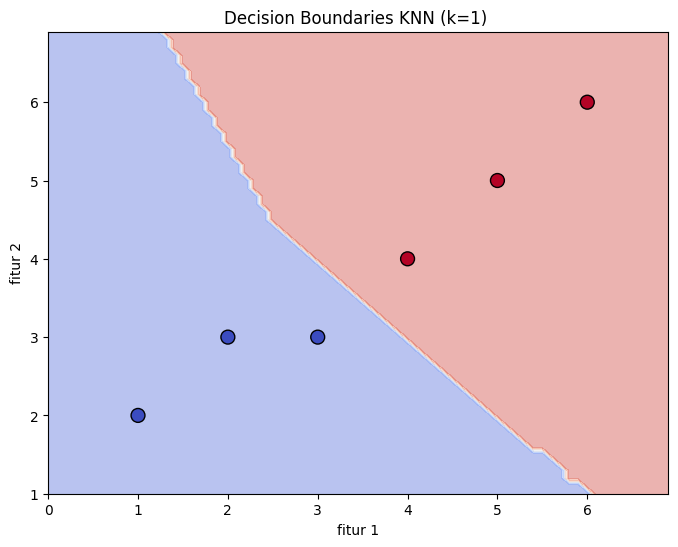

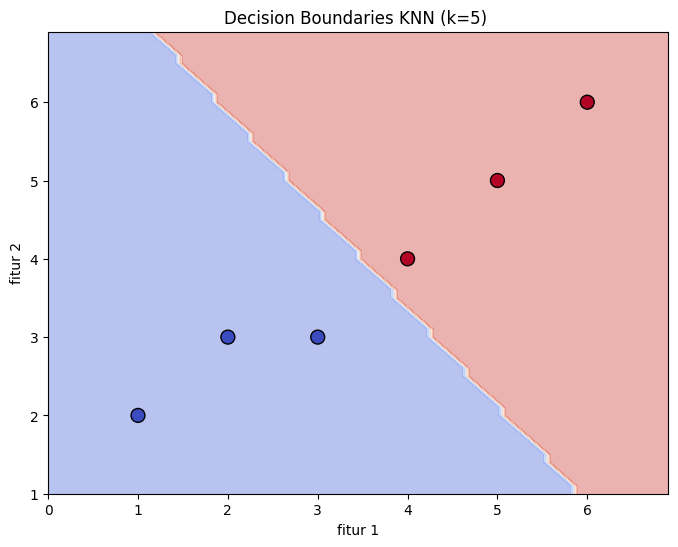

In [ ]:
plot_batas_knn(1)

plot_batas_knn(5)


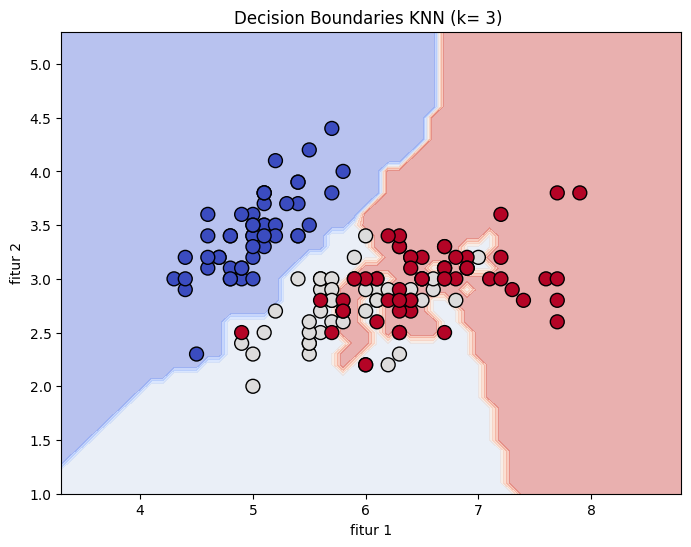

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
x = iris.data[:,:2] # ambil 2 fitur aja, yaitu sepal length dan sepal width, agar visualisasinya 2D
y = iris.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
knn = KNeighborsClassifier(n_neighbors=3)

#train model
knn.fit(x_train,y_train)

#buat prediksi
y_pred = knn.predict(x_test)
x_min, x_max, =x[:,0].min() -1, x[:,0].max() + 1
y_min, y_max, =x[:,1].min() -1, x[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min,x_max, 0.1),
                      np.arange(y_min,y_max, 0.1))
#perediksi kelas untuk setiap titik di grid
z = knn.predict(np.c_[xx.ravel(),yy.ravel()]) # mengubah array 2D menjadi 1D, c_ untuk combine
z = z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, z, alpha=0.4, cmap='coolwarm')

plt.scatter(x[:,0], x[:,1], c = y,cmap= 'coolwarm', s=100, edgecolors='k', label='data points' )
# c = y gambar titiknya punya warna sesuai kelas pada y, s adalah ukuran datan point
plt.title(f'Decision Boundaries KNN (k= 3) ')
plt.xlabel('fitur 1')
plt.ylabel('fitur 2')
plt.show()

# Generalization, Overfitting, Underfitting

*   Generalization yang Baik: Jika akurasi model pada data latih dan data uji cukup konsisten dan tidak terlalu berbeda, ini adalah indikator bahwa
model mampu mengeneralisasi dengan baik.
*   Overfitting: Jika akurasi data latih sangat tinggi (misalnya, >95%), tetapi akurasi data uji jauh lebih rendah (misalnya, <70%), ini adalah tanda bahwa model mengalami overfitting. Model "menghafal data latih tetapi tidak mampu memprediksi dengan baik pada data baru.
*   Underfitting: Jika akurasi data latih dan data uji sama-sama rendah (misalnya, keduanya <60%), model mengalami underfitting, yang berarti model terlalu sederhana dan tidak mampu menangkap pola dalam data.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
x = iris.data[:,:2] # ambil 2 fitur aja, yaitu sepal length dan sepal width, agar visualisasinya 2D
y = iris.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

# Generalization

OPTIMAL CASE (k=50)

In [ ]:
from sklearn.metrics import accuracy_score
knn_optimal = KNeighborsClassifier(n_neighbors=5)

#train
knn_optimal.fit(x_train,y_train)
akurasi_optimal_train = accuracy_score(y_train,knn_optimal.predict(x_train))# data training dan hasil prediksi
akurasi_optimal_test = accuracy_score(y_test,knn_optimal.predict(x_test))# data training dan hasil prediksi
print(f"Good Generalization (k=5) - Training Accuracy: {akurasi_optimal_train * 100:.2f}%") # float 2 angka di belakang koma
print(f"Good Generalization (k=5) - test Accuracy: {akurasi_optimal_test * 100:.2f}%")

Good Generalization (k=5) - Training Accuracy: 81.67%
Good Generalization (k=5) - test Accuracy: 86.67%


# Overfitting

In [ ]:
from sklearn.metrics import accuracy_score
# overfitting case
knn_overfitting = KNeighborsClassifier(n_neighbors=1) # n_neighbors di ganti jadi 1

#train
knn_overfitting.fit(x_train,y_train)
akurasi_overfitting_train = accuracy_score(y_train,knn_overfitting.predict(x_train))# data training dan hasil prediksi
akurasi_overfitting_test = accuracy_score(y_test,knn_overfitting.predict(x_test))# data training dan hasil prediksi
print(f"Overfitting (k=1) - Training Accuracy: {akurasi_overfitting_train * 100:.2f}%") # float 2 angka di belakang koma
print(f"Overfitting (k=1) - test Accuracy: {akurasi_overfitting_test * 100:.2f}%")

Overfitting (k=1) - Training Accuracy: 94.17%
Overfitting (k=1) - test Accuracy: 66.67%


# Underfitting

In [ ]:
from sklearn.metrics import accuracy_score
knn_underfitting = KNeighborsClassifier(n_neighbors=120)

#train
knn_underfitting.fit(x_train,y_train)
akurasi_underfitting_train = accuracy_score(y_train,knn_underfitting.predict(x_train))# data training dan hasil prediksi
akurasi_underfitting_test = accuracy_score(y_test,knn_underfitting.predict(x_test))# data training dan hasil prediksi
print(f"Underfitting (k=120) - Training Accuracy: {akurasi_underfitting_train * 100:.2f}%") # float 2 angka di belakang koma
print(f"Underfitting (k=120) - test Accuracy: {akurasi_underfitting_test * 100:.2f}%")

Underfitting (k=120) - Training Accuracy: 36.67%
Underfitting (k=120) - test Accuracy: 20.00%


# Tugas

Gunakan data Sklearn untuk Breast cancer menggunakan KNN Classifier (Ambil 2 fitur pertama aja), gunakan n_neighbor dengan mengambil jumlah 2 angka dari belakang di NIM mahasiswa masing masing (misal i.2211266, maka n_neighbor 66)

Buat visualisasi decision boundaris dan sebutkan apakah Generalization, Overfitting, Underfitting


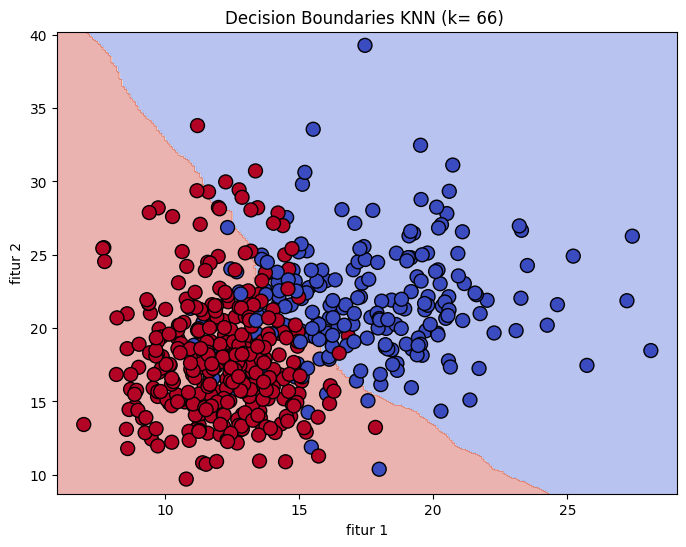

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer_data = load_breast_cancer()
x = cancer_data.data[:,:2] # untuk ambil 2 fitur aja
y = cancer_data.target

# disini karna nim saya i.2211266 maka n_neighbors = 66
nim = 66

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=1)
knn = KNeighborsClassifier(n_neighbors=nim)

#train model
knn.fit(x_train,y_train)

#buat prediksi
y_pred = knn.predict(x_test)
x_min, x_max, =x[:,0].min() -1, x[:,0].max() + 1
y_min, y_max, =x[:,1].min() -1, x[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min,x_max, 0.1),
                      np.arange(y_min,y_max, 0.1))
#perediksi kelas untuk setiap titik di grid
z = knn.predict(np.c_[xx.ravel(),yy.ravel()]) # mengubah array 2D menjadi 1D, c_ untuk combine
z = z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, z, alpha=0.4, cmap='coolwarm')

plt.scatter(x[:,0], x[:,1], c = y,cmap= 'coolwarm', s=100, edgecolors='k', label='data points' )
# c = y gambar titiknya punya warna sesuai kelas pada y, s adalah ukuran datan point
plt.title(f'Decision Boundaries KNN (k= 66) ')
plt.xlabel('fitur 1')
plt.ylabel('fitur 2')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
knn_nim = KNeighborsClassifier(n_neighbors=nim)

#train
knn_nim.fit(x_train,y_train)
akurasi_train = accuracy_score(y_train,knn_nim.predict(x_train))# data training dan hasil prediksi
akurasi_test = accuracy_score(y_test,knn_nim.predict(x_test))# data training dan hasil prediksi
print(f"n_neighbors (k=66) - Training Accuracy: {akurasi_train * 100:.2f}%") # float 2 angka di belakang koma
print(f"n_neighbors (k=66) - Test Accuracy: {akurasi_test * 100:.2f}%")

n_neighbors (k=66) - Training Accuracy: 91.08%
n_neighbors (k=66) - Test Accuracy: 81.12%


Ternyata ketika n_neighbors = 66, mendapatkan hasil:<br> Training Accuracy: 91.08% <br> Test Accuracy: 81.12% <br>

Ini menandakan bahwa model yang dibuat dengan pembagian data train 75% dan test 25% serta n_neighbors = 66, bahwa model ini  **generalisasi yang baik (Good Generalization)**.seperti yang kita tahu jika akurasi model pada data latih dan data uji cukup konsisten dan tidak terlalu berbeda, ini merupakan indikator bahwa model mampu mengeneralisasi dengan baik


<br>
<a href="https://www.linkedin.com/in/m-riziq-sa"><img src="https://img.shields.io/badge/-© 2024 M. Riziq Sirfatullah Alfarizi-417DAC?style=for-the-badge&logoColor=white"/></a>